# Waste Image Classification Using CNN and Transfer Learning

This notebook compares different deep learning approaches for waste image classification. The task is to classify images into six categories: cardboard, glass, metal, paper, plastic, and trash.

We use the cleaned and augmented TrashNet dataset, which is organized into training, validation, and test folders. The training set contains augmented images, while the validation and test sets are used to evaluate how well the models generalize to unseen data.

The main goal is to compare a custom CNN trained from scratch with several transfer learning models. The evaluated models are:

1. Custom CNN trained from scratch  
2. MobileNetV2 trained from scratch  
3. MobileNetV2 with ImageNet pre-trained weights  
4. EfficientNetB0 with ImageNet pre-trained weights  
5. ResNet50 with ImageNet pre-trained weights  

Each model is evaluated using test accuracy, test loss, precision, recall, F1-score, confusion matrix, and macro ROC-AUC. These metrics allow us to compare both the overall performance and the class-specific performance.

The final comparison shows that pre-trained transfer learning models perform better than models trained fully from scratch. ResNet50 achieves the best overall result, followed by EfficientNetB0. This confirms that using ImageNet pre-trained weights is beneficial for our relatively small waste classification dataset.

In [ ]:
# ============================================================
# 1) Imports and Settings
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Flatten,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

In [ ]:
# ============================================================
# 2) Global Settings
# ============================================================


PROJECT_ROOT = Path.cwd()

dataset_path = PROJECT_ROOT / "dataset" / "clean_split_dataset_augmented"
train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "val")
test_dir  = os.path.join(dataset_path, "test")

img_height = 224
img_width = 224
batch_size = 32

os.makedirs("model", exist_ok=True)

In [8]:
# ============================================================
# 3) Dataset Loader
# ============================================================

def load_generators(preprocessing_function=None, rescale=None):
    """
    Create train, validation and test generators.
    """

    train_gen = ImageDataGenerator(
        preprocessing_function=preprocessing_function,
        rescale=rescale
    )

    valid_gen = ImageDataGenerator(
        preprocessing_function=preprocessing_function,
        rescale=rescale
    )

    test_gen = ImageDataGenerator(
        preprocessing_function=preprocessing_function,
        rescale=rescale
    )

    train_dataset = train_gen.flow_from_directory(
        train_dir,
        class_mode="categorical",
        target_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=True
    )

    valid_dataset = valid_gen.flow_from_directory(
        valid_dir,
        class_mode="categorical",
        target_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=False
    )

    test_dataset = test_gen.flow_from_directory(
        test_dir,
        class_mode="categorical",
        target_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=False
    )

    return train_dataset, valid_dataset, test_dataset

In [9]:
# ============================================================
# 4) Callbacks
# ============================================================

def create_callbacks(model_name, patience=10):
    """
    Create callbacks for training.
    """

    return [
        ModelCheckpoint(
            filepath=f"model/{model_name}.keras",
            monitor="val_loss",
            verbose=1,
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            verbose=1,
            min_lr=1e-6
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1
        )
    ]

## Helper Functions

In [10]:
# ============================================================
# 5) Custom CNN Builder
# ============================================================

def build_custom_cnn(num_classes):
    """
    Build a custom CNN model from scratch.
    """

    model = Sequential(name="custom_cnn")

    filters = [16, 32, 32, 64, 128, 256]

    for i, f in enumerate(filters):
        if i == 0:
            model.add(Conv2D(
                f, (3, 3),
                activation="relu",
                kernel_initializer="he_uniform",
                padding="same",
                input_shape=(img_height, img_width, 3)
            ))
        else:
            model.add(Conv2D(
                f, (3, 3),
                activation="relu",
                kernel_initializer="he_uniform",
                padding="same"
            ))

        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu", kernel_initializer="he_uniform"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))

    return model

In [11]:
# ============================================================
# 6) Pretrained Model Builder
# ============================================================

def build_pretrained_model(base_model_class, num_classes, model_name):
    """
    Build a pretrained transfer learning model.
    """

    base_model = base_model_class(
        weights="imagenet",
        include_top=False,
        input_shape=(img_height, img_width, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name=model_name
    )

    return model

In [12]:
# ============================================================
# 7) Training Function
# ============================================================

def train_model(model, train_dataset, valid_dataset, model_name, epochs=30, lr=1e-4):
    """
    Compile and train a model.
    """

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_dataset,
        validation_data=valid_dataset,
        epochs=epochs,
        callbacks=create_callbacks(model_name),
        verbose=2
    )

    return history

In [13]:
# ============================================================
# 8) Plot Training Curves
# ============================================================

def plot_training_curves(history, title):
    """
    Plot loss and accuracy curves.
    """

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# 9) Evaluation Function
# ============================================================

def evaluate_model(model, test_dataset, model_name):
    """
    Evaluate model and return metrics.
    """

    test_dataset.reset()

    test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

    y_true = test_dataset.classes

    y_prob = model.predict(
        test_dataset,
        steps=len(test_dataset),
        verbose=1
    )

    y_pred = np.argmax(y_prob, axis=1)

    class_labels = list(test_dataset.class_indices.keys())

    print(f"\n{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_acc:.4f}\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        zero_division=0
    )

    metrics_df = pd.DataFrame({
        "Class": class_labels,
        "Precision": precision,
        "Recall / Class Accuracy": recall,
        "F1-score": f1,
        "Support": support
    })

    display(metrics_df)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(len(class_labels))
    )

    macro_roc_auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    print(f"{model_name} Macro ROC AUC: {macro_roc_auc:.4f}")

    return {
        "model": model_name,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "macro_roc_auc": macro_roc_auc,
        "metrics_df": metrics_df,
        "y_true": y_true,
        "y_prob": y_prob,
        "class_labels": class_labels
    }

In [15]:
# ============================================================
# 10) ROC Curve Function
# ============================================================

def plot_roc_curves(result):
    """
    Plot ROC curves per class.
    """

    y_true = result["y_true"]
    y_prob = result["y_prob"]
    class_labels = result["class_labels"]
    model_name = result["model"]

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(len(class_labels))
    )

    plt.figure(figsize=(8, 6))

    for class_index, class_name in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(
            y_true_bin[:, class_index],
            y_prob[:, class_index]
        )

        class_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} AUC = {class_auc:.2f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
# ============================================================
# MobileNetV2 From Scratch Builder
# ============================================================

def build_mobilenetv2_from_scratch(num_classes):
    """
    Build MobileNetV2 from scratch without pretrained ImageNet weights.
    """

    base_model = MobileNetV2(
        weights=None,
        include_top=False,
        input_shape=(img_height, img_width, 3)
    )

    base_model.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name="mobilenetv2_from_scratch"
    )

    return model

# Custom CNN

Found 2490 images belonging to 6 classes.
Found 502 images belonging to 6 classes.
Found 258 images belonging to 6 classes.


Model: "custom_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 16)      64        
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 32)      128    

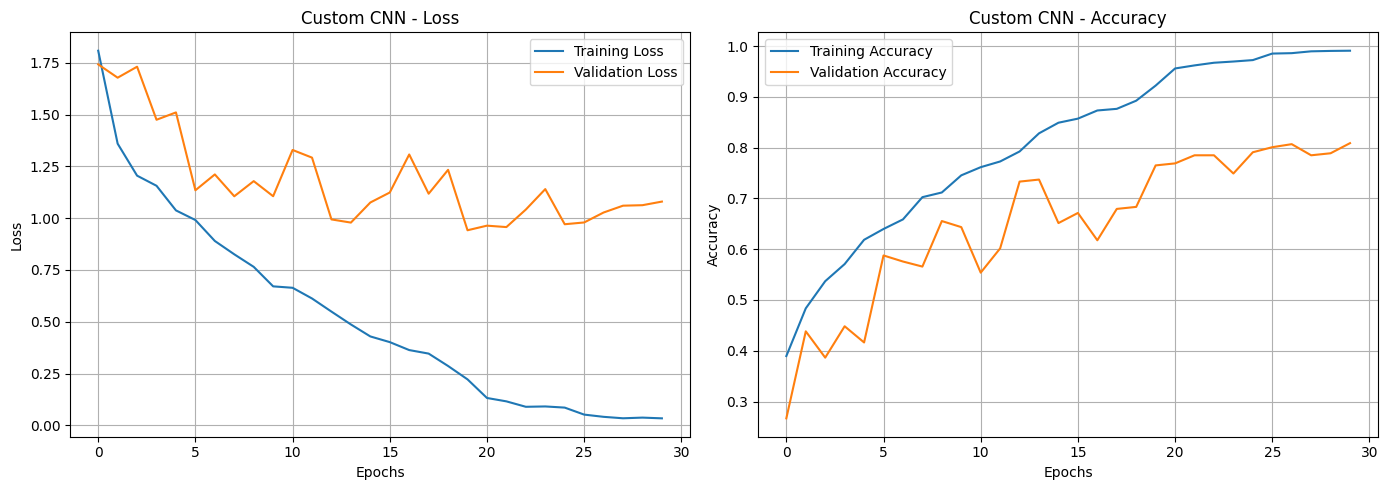

9/9 [==============================] - 1s 42ms/step

Custom CNN Test Loss: 0.7953
Custom CNN Test Accuracy: 0.8062

              precision    recall  f1-score   support

   cardboard       0.83      0.83      0.83        41
       glass       0.76      0.73      0.74        51
       metal       0.80      0.76      0.78        42
       paper       0.83      0.90      0.87        61
     plastic       0.86      0.77      0.81        48
       trash       0.68      0.87      0.76        15

    accuracy                           0.81       258
   macro avg       0.79      0.81      0.80       258
weighted avg       0.81      0.81      0.81       258



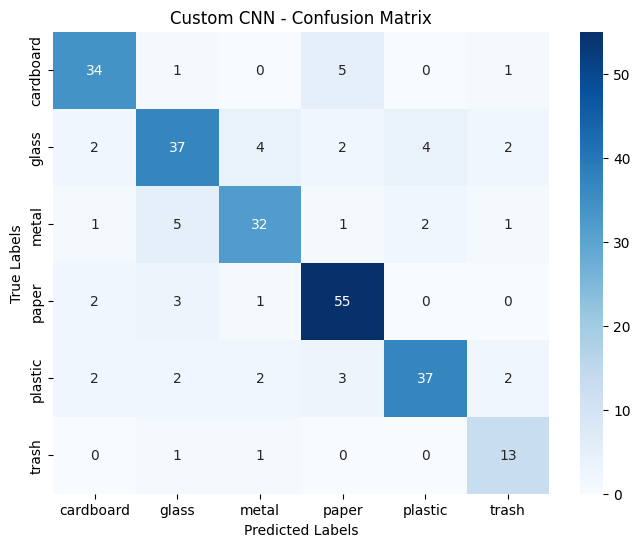

,Class,Precision,Recall / Class Accuracy,F1-score,Support
0,cardboard,0.829268,0.829268,0.829268,41
1,glass,0.755102,0.725490,0.740000,51
2,metal,0.800000,0.761905,0.780488,42
3,paper,0.833333,0.901639,0.866142,61
4,plastic,0.860465,0.770833,0.813187,48
5,trash,0.684211,0.866667,0.764706,15


Custom CNN Macro ROC AUC: 0.9617


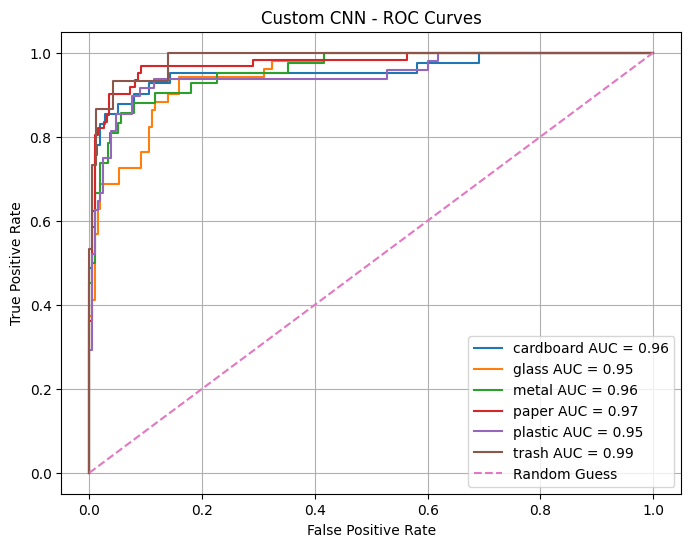

In [17]:
train_dataset, valid_dataset, test_dataset = load_generators(rescale=1./255)

class_names = list(train_dataset.class_indices.keys())
num_classes = len(class_names)

cnn_model = build_custom_cnn(num_classes)
cnn_model.summary()

cnn_history = train_model(
    cnn_model,
    train_dataset,
    valid_dataset,
    model_name="custom_cnn",
    epochs=100,
    lr=1e-3
)

plot_training_curves(cnn_history, "Custom CNN")

cnn_result = evaluate_model(
    cnn_model,
    test_dataset,
    model_name="Custom CNN"
)

plot_roc_curves(cnn_result)

# MobileNetV2 pretrained

Found 2490 images belonging to 6 classes.
Found 502 images belonging to 6 classes.
Found 258 images belonging to 6 classes.
Epoch 1/30

Epoch 1: val_loss improved from inf to 1.75385, saving model to model\mobilenetv2_pretrained.keras
78/78 - 15s - loss: 2.1883 - accuracy: 0.2008 - val_loss: 1.7539 - val_accuracy: 0.2849 - lr: 1.0000e-04 - 15s/epoch - 186ms/step
Epoch 2/30

Epoch 2: val_loss improved from 1.75385 to 1.42430, saving model to model\mobilenetv2_pretrained.keras
78/78 - 13s - loss: 1.7542 - accuracy: 0.3108 - val_loss: 1.4243 - val_accuracy: 0.4243 - lr: 1.0000e-04 - 13s/epoch - 166ms/step
Epoch 3/30

Epoch 3: val_loss improved from 1.42430 to 1.24020, saving model to model\mobilenetv2_pretrained.keras
78/78 - 13s - loss: 1.4636 - accuracy: 0.4369 - val_loss: 1.2402 - val_accuracy: 0.5299 - lr: 1.0000e-04 - 13s/epoch - 163ms/step
Epoch 4/30

Epoch 4: val_loss improved from 1.24020 to 1.09994, saving model to model\mobilenetv2_pretrained.keras
78/78 - 13s - loss: 1.3007 - a

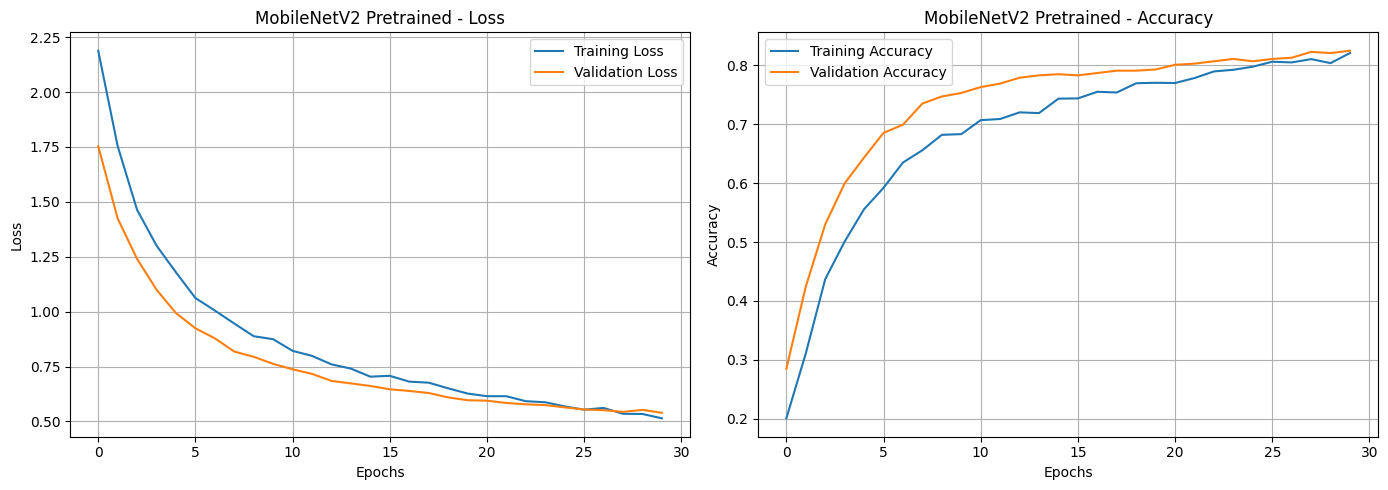

9/9 [==============================] - 2s 140ms/step

MobileNetV2 Pretrained Test Loss: 0.5783
MobileNetV2 Pretrained Test Accuracy: 0.7907

              precision    recall  f1-score   support

   cardboard       0.92      0.88      0.90        41
       glass       0.79      0.73      0.76        51
       metal       0.74      0.76      0.75        42
       paper       0.85      0.82      0.83        61
     plastic       0.79      0.77      0.78        48
       trash       0.52      0.80      0.63        15

    accuracy                           0.79       258
   macro avg       0.77      0.79      0.78       258
weighted avg       0.80      0.79      0.79       258



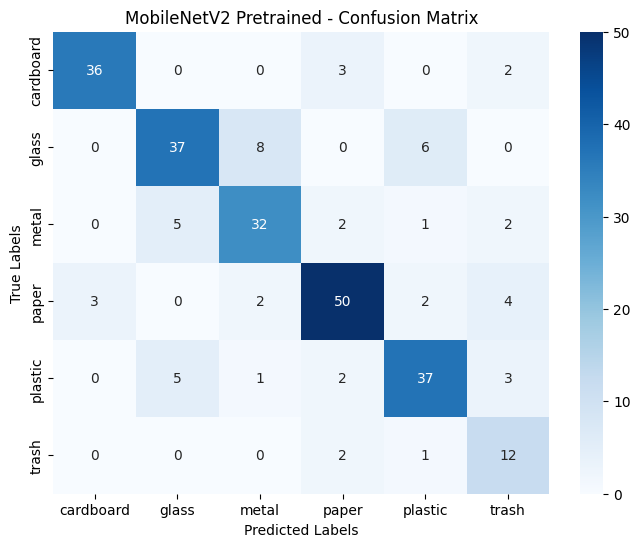

,Class,Precision,Recall / Class Accuracy,F1-score,Support
0,cardboard,0.923077,0.878049,0.900000,41
1,glass,0.787234,0.725490,0.755102,51
2,metal,0.744186,0.761905,0.752941,42
3,paper,0.847458,0.819672,0.833333,61
4,plastic,0.787234,0.770833,0.778947,48
5,trash,0.521739,0.800000,0.631579,15


MobileNetV2 Pretrained Macro ROC AUC: 0.9666


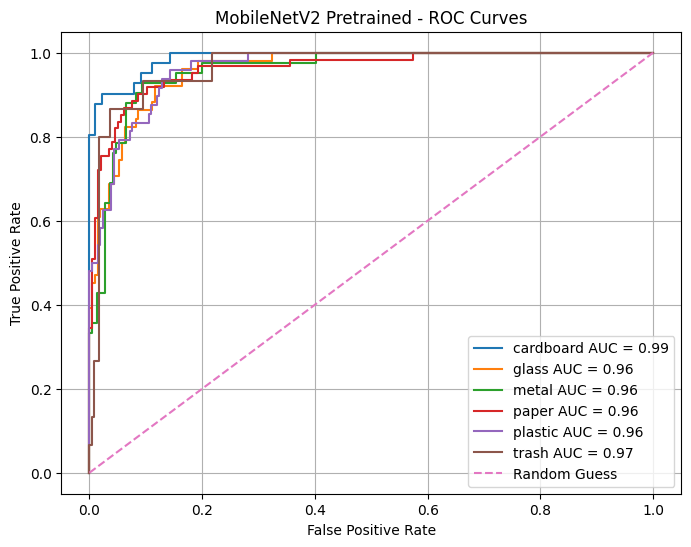

In [18]:
train_mob, valid_mob, test_mob = load_generators(
    preprocessing_function=mobilenet_preprocess
)

mobilenet_model = build_pretrained_model(
    MobileNetV2,
    num_classes,
    model_name="mobilenetv2_pretrained"
)

mobilenet_history = train_model(
    mobilenet_model,
    train_mob,
    valid_mob,
    model_name="mobilenetv2_pretrained",
    epochs=30,
    lr=1e-4
)

plot_training_curves(mobilenet_history, "MobileNetV2 Pretrained")

mobilenet_result = evaluate_model(
    mobilenet_model,
    test_mob,
    model_name="MobileNetV2 Pretrained"
)

plot_roc_curves(mobilenet_result)

# EfficientNetB0 pretrained

Found 2490 images belonging to 6 classes.
Found 502 images belonging to 6 classes.
Found 258 images belonging to 6 classes.
Epoch 1/30

Epoch 1: val_loss improved from inf to 1.45305, saving model to model\efficientnetb0_pretrained.keras
78/78 - 26s - loss: 1.6676 - accuracy: 0.3056 - val_loss: 1.4531 - val_accuracy: 0.4502 - lr: 1.0000e-04 - 26s/epoch - 331ms/step
Epoch 2/30

Epoch 2: val_loss improved from 1.45305 to 1.21950, saving model to model\efficientnetb0_pretrained.keras
78/78 - 22s - loss: 1.3759 - accuracy: 0.5060 - val_loss: 1.2195 - val_accuracy: 0.5996 - lr: 1.0000e-04 - 22s/epoch - 286ms/step
Epoch 3/30

Epoch 3: val_loss improved from 1.21950 to 1.06094, saving model to model\efficientnetb0_pretrained.keras
78/78 - 22s - loss: 1.2076 - accuracy: 0.5815 - val_loss: 1.0609 - val_accuracy: 0.6554 - lr: 1.0000e-04 - 22s/epoch - 280ms/step
Epoch 4/30

Epoch 4: val_loss improved from 1.06094 to 0.94677, saving model to model\efficientnetb0_pretrained.keras
78/78 - 22s - loss

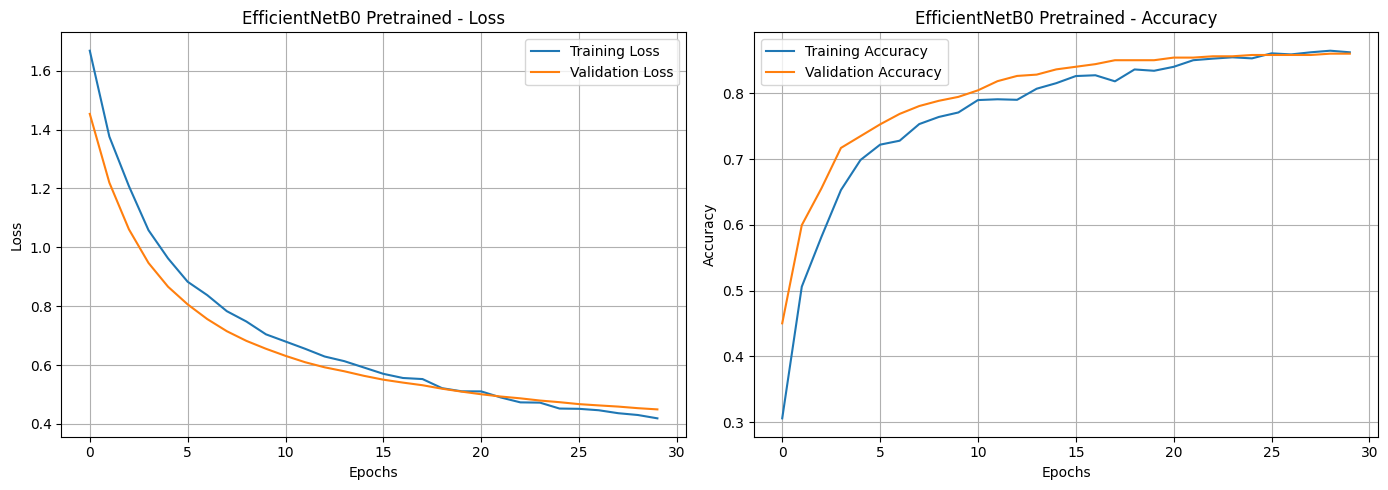

9/9 [==============================] - 3s 198ms/step

EfficientNetB0 Pretrained Test Loss: 0.4547
EfficientNetB0 Pretrained Test Accuracy: 0.8256

              precision    recall  f1-score   support

   cardboard       0.93      0.95      0.94        41
       glass       0.86      0.73      0.79        51
       metal       0.71      0.81      0.76        42
       paper       0.95      0.87      0.91        61
     plastic       0.84      0.77      0.80        48
       trash       0.52      0.87      0.65        15

    accuracy                           0.83       258
   macro avg       0.80      0.83      0.81       258
weighted avg       0.84      0.83      0.83       258



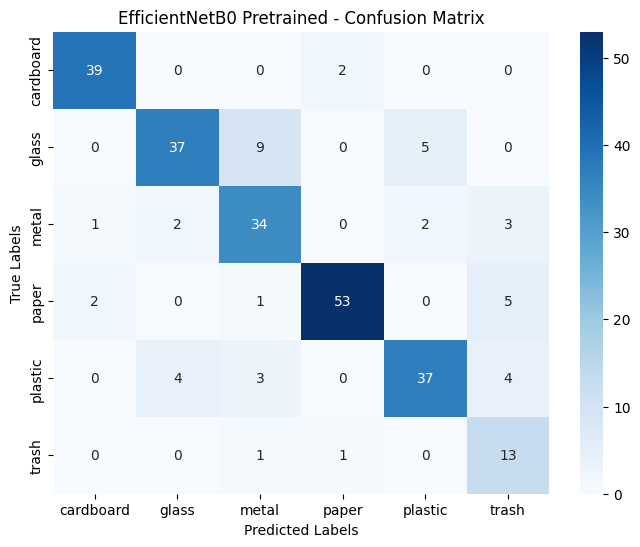

,Class,Precision,Recall / Class Accuracy,F1-score,Support
0,cardboard,0.928571,0.951220,0.939759,41
1,glass,0.860465,0.725490,0.787234,51
2,metal,0.708333,0.809524,0.755556,42
3,paper,0.946429,0.868852,0.905983,61
4,plastic,0.840909,0.770833,0.804348,48
5,trash,0.520000,0.866667,0.650000,15


EfficientNetB0 Pretrained Macro ROC AUC: 0.9801


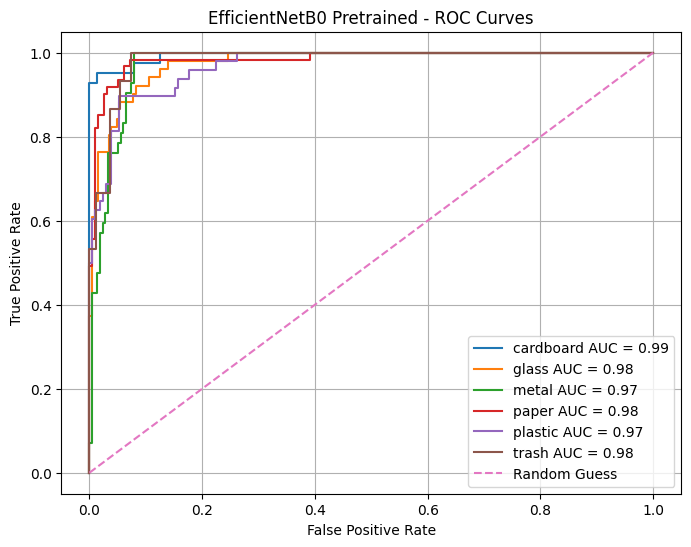

In [19]:
train_eff, valid_eff, test_eff = load_generators(
    preprocessing_function=efficientnet_preprocess
)

efficientnet_model = build_pretrained_model(
    EfficientNetB0,
    num_classes,
    model_name="efficientnetb0_pretrained"
)

efficientnet_history = train_model(
    efficientnet_model,
    train_eff,
    valid_eff,
    model_name="efficientnetb0_pretrained",
    epochs=30,
    lr=1e-4
)

plot_training_curves(efficientnet_history, "EfficientNetB0 Pretrained")

efficientnet_result = evaluate_model(
    efficientnet_model,
    test_eff,
    model_name="EfficientNetB0 Pretrained"
)

plot_roc_curves(efficientnet_result)

# ResNet50 pretrained

Found 2490 images belonging to 6 classes.
Found 502 images belonging to 6 classes.
Found 258 images belonging to 6 classes.
Epoch 1/30

Epoch 1: val_loss improved from inf to 1.36773, saving model to model\resnet50_pretrained.keras
78/78 - 47s - loss: 1.9371 - accuracy: 0.2831 - val_loss: 1.3677 - val_accuracy: 0.4761 - lr: 1.0000e-04 - 47s/epoch - 608ms/step
Epoch 2/30

Epoch 2: val_loss improved from 1.36773 to 1.05441, saving model to model\resnet50_pretrained.keras
78/78 - 46s - loss: 1.4133 - accuracy: 0.4675 - val_loss: 1.0544 - val_accuracy: 0.6135 - lr: 1.0000e-04 - 46s/epoch - 595ms/step
Epoch 3/30

Epoch 3: val_loss improved from 1.05441 to 0.85366, saving model to model\resnet50_pretrained.keras
78/78 - 46s - loss: 1.1091 - accuracy: 0.5948 - val_loss: 0.8537 - val_accuracy: 0.7072 - lr: 1.0000e-04 - 46s/epoch - 594ms/step
Epoch 4/30

Epoch 4: val_loss improved from 0.85366 to 0.78254, saving model to model\resnet50_pretrained.keras
78/78 - 47s - loss: 0.9872 - accuracy: 0.6

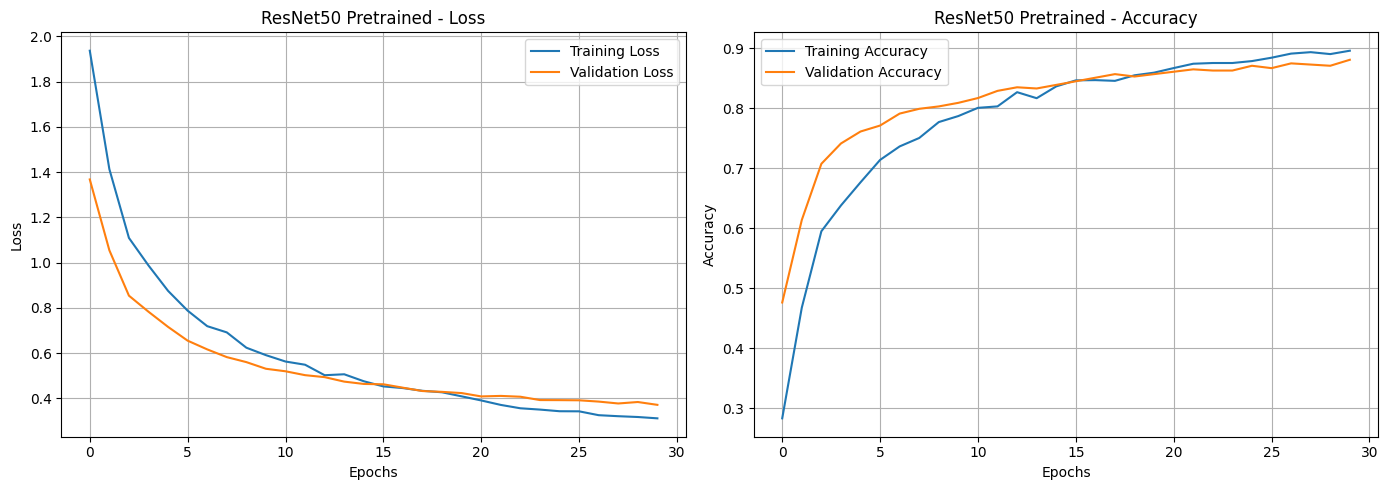

9/9 [==============================] - 9s 636ms/step

ResNet50 Pretrained Test Loss: 0.4149
ResNet50 Pretrained Test Accuracy: 0.8566

              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        41
       glass       0.84      0.80      0.82        51
       metal       0.81      0.90      0.85        42
       paper       0.89      0.89      0.89        61
     plastic       0.86      0.79      0.83        48
       trash       0.81      0.87      0.84        15

    accuracy                           0.86       258
   macro avg       0.85      0.86      0.85       258
weighted avg       0.86      0.86      0.86       258



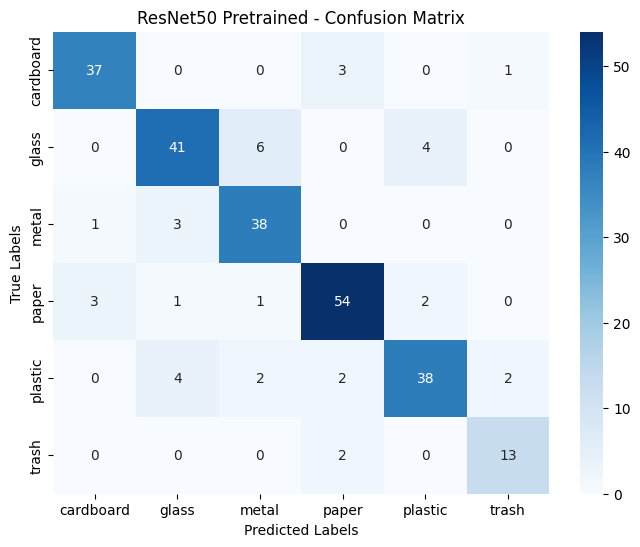

,Class,Precision,Recall / Class Accuracy,F1-score,Support
0,cardboard,0.902439,0.902439,0.902439,41
1,glass,0.836735,0.803922,0.820000,51
2,metal,0.808511,0.904762,0.853933,42
3,paper,0.885246,0.885246,0.885246,61
4,plastic,0.863636,0.791667,0.826087,48
5,trash,0.812500,0.866667,0.838710,15


ResNet50 Pretrained Macro ROC AUC: 0.9818


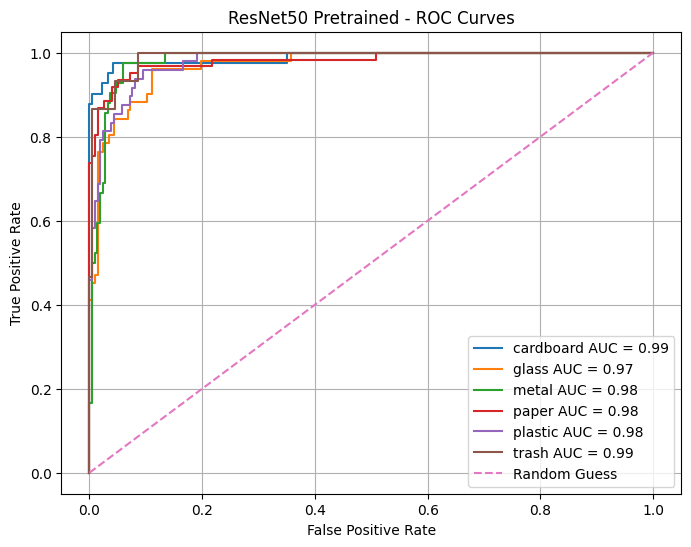

In [20]:
train_res, valid_res, test_res = load_generators(
    preprocessing_function=resnet_preprocess
)

resnet_model = build_pretrained_model(
    ResNet50,
    num_classes,
    model_name="resnet50_pretrained"
)

resnet_history = train_model(
    resnet_model,
    train_res,
    valid_res,
    model_name="resnet50_pretrained",
    epochs=30,
    lr=1e-4
)

plot_training_curves(resnet_history, "ResNet50 Pretrained")

resnet_result = evaluate_model(
    resnet_model,
    test_res,
    model_name="ResNet50 Pretrained"
)

plot_roc_curves(resnet_result)

# MobileNetV2 From Scratch

Found 2490 images belonging to 6 classes.
Found 502 images belonging to 6 classes.
Found 258 images belonging to 6 classes.
Model: "mobilenetv2_from_scratch"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_4[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                  

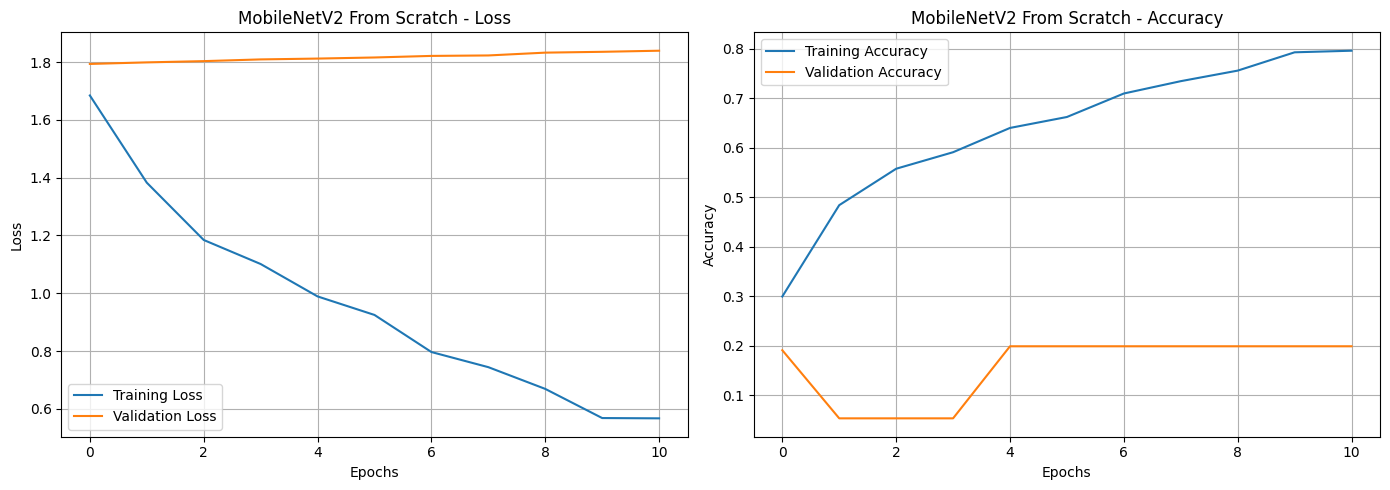

9/9 [==============================] - 3s 173ms/step

MobileNetV2 From Scratch Test Loss: 1.7934
MobileNetV2 From Scratch Test Accuracy: 0.1860

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        41
       glass       0.00      0.00      0.00        51
       metal       0.00      0.00      0.00        42
       paper       0.00      0.00      0.00        61
     plastic       0.19      1.00      0.31        48
       trash       0.00      0.00      0.00        15

    accuracy                           0.19       258
   macro avg       0.03      0.17      0.05       258
weighted avg       0.03      0.19      0.06       258



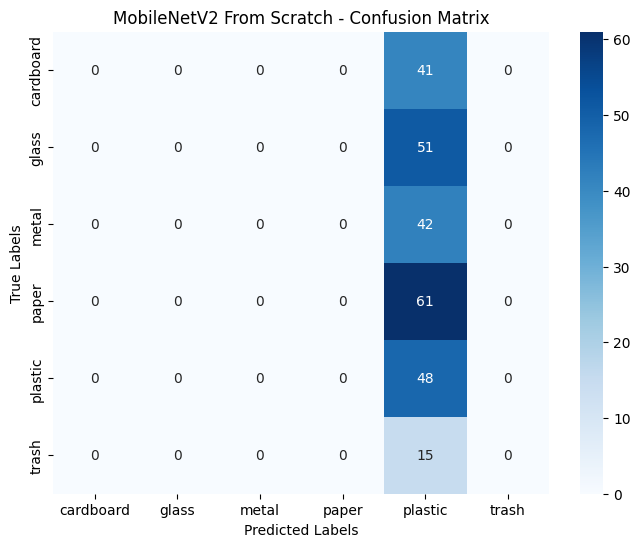

,Class,Precision,Recall / Class Accuracy,F1-score,Support
0,cardboard,0.000000,0.0,0.000000,41
1,glass,0.000000,0.0,0.000000,51
2,metal,0.000000,0.0,0.000000,42
3,paper,0.000000,0.0,0.000000,61
4,plastic,0.186047,1.0,0.313725,48
5,trash,0.000000,0.0,0.000000,15


MobileNetV2 From Scratch Macro ROC AUC: 0.5000


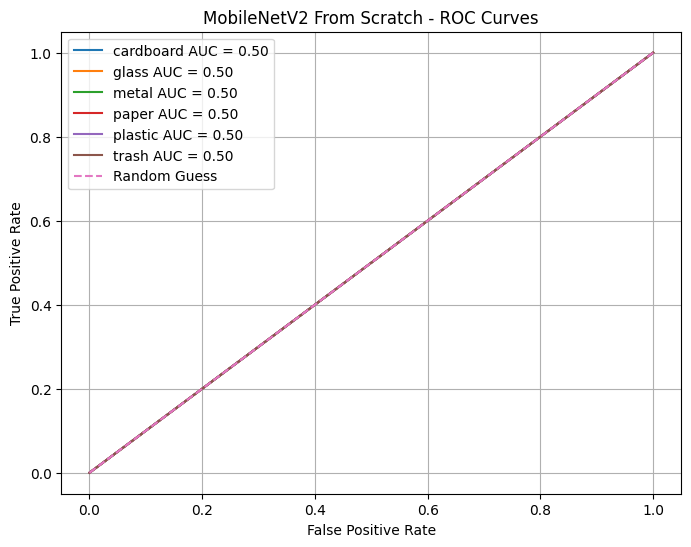

In [21]:
# ============================================================
# Run MobileNetV2 From Scratch
# ============================================================

train_scratch, valid_scratch, test_scratch = load_generators(
    preprocessing_function=mobilenet_preprocess
)

mobilenet_scratch_model = build_mobilenetv2_from_scratch(num_classes)

mobilenet_scratch_model.summary()

mobilenet_scratch_history = train_model(
    mobilenet_scratch_model,
    train_scratch,
    valid_scratch,
    model_name="mobilenetv2_from_scratch",
    epochs=100,
    lr=1e-4
)

plot_training_curves(
    mobilenet_scratch_history,
    "MobileNetV2 From Scratch"
)

mobilenet_scratch_result = evaluate_model(
    mobilenet_scratch_model,
    test_scratch,
    model_name="MobileNetV2 From Scratch"
)

plot_roc_curves(mobilenet_scratch_result)

# Final comparison table 

In [22]:
# ============================================================
# Final Model Comparison Table
# ============================================================

results_summary = pd.DataFrame([
    {
        "Model": cnn_result["model"],
        "Approach": "Custom CNN from scratch",
        "Test Accuracy": cnn_result["test_accuracy"],
        "Test Loss": cnn_result["test_loss"],
        "Macro ROC AUC": cnn_result["macro_roc_auc"]
    },
    {
        "Model": mobilenet_scratch_result["model"],
        "Approach": "MobileNetV2 from scratch",
        "Test Accuracy": mobilenet_scratch_result["test_accuracy"],
        "Test Loss": mobilenet_scratch_result["test_loss"],
        "Macro ROC AUC": mobilenet_scratch_result["macro_roc_auc"]
    },
    {
        "Model": mobilenet_result["model"],
        "Approach": "MobileNetV2 pretrained ImageNet",
        "Test Accuracy": mobilenet_result["test_accuracy"],
        "Test Loss": mobilenet_result["test_loss"],
        "Macro ROC AUC": mobilenet_result["macro_roc_auc"]
    },
    {
        "Model": efficientnet_result["model"],
        "Approach": "EfficientNetB0 pretrained ImageNet",
        "Test Accuracy": efficientnet_result["test_accuracy"],
        "Test Loss": efficientnet_result["test_loss"],
        "Macro ROC AUC": efficientnet_result["macro_roc_auc"]
    },
    {
        "Model": resnet_result["model"],
        "Approach": "ResNet50 pretrained ImageNet",
        "Test Accuracy": resnet_result["test_accuracy"],
        "Test Loss": resnet_result["test_loss"],
        "Macro ROC AUC": resnet_result["macro_roc_auc"]
    }
])

results_summary = results_summary.sort_values(
    by="Macro ROC AUC",
    ascending=False
).reset_index(drop=True)

results_summary

,Model,Approach,Test Accuracy,Test Loss,Macro ROC AUC
0,ResNet50 Pretrained,ResNet50 pretrained ImageNet,0.856589,0.414866,0.981811
1,EfficientNetB0 Pretrained,EfficientNetB0 pretrained ImageNet,0.825581,0.454653,0.980079
2,MobileNetV2 Pretrained,MobileNetV2 pretrained ImageNet,0.790698,0.578332,0.966599
3,Custom CNN,Custom CNN from scratch,0.806202,0.795339,0.961726
4,MobileNetV2 From Scratch,MobileNetV2 from scratch,0.186047,1.793396,0.500000
